# <center>Support Vector Machine (SVM)

## Table of Algorithms
### Linear SVM
1. Hard-margin SVM (GD)
2. Soft-margin SVM (GD) 
3. Soft-margin SVM (SGD)
4. Soft-margin SVM (Mini-batch GD)
### Kernel SVM
5. Kernel SVM (RBF)

---

Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from hard_margin_gd import hinge_loss

Importing data

In [2]:
import os
os.path.abspath(os.path.join(os.path.dirname('02_logistic_regression'), '..'))

bezdekIris = '../data/iris/bezdekIris.data'
df = pd.read_csv(bezdekIris)

---

Checking data

In [3]:
df

,5.1,3.5,1.4,0.2,Iris-setosa
0,4.9,3.0,1.4,0.2,Iris-setosa
1,4.7,3.2,1.3,0.2,Iris-setosa
2,4.6,3.1,1.5,0.2,Iris-setosa
3,5.0,3.6,1.4,0.2,Iris-setosa
4,5.4,3.9,1.7,0.4,Iris-setosa
...,...,...,...,...,...
144,6.7,3.0,5.2,2.3,Iris-virginica
145,6.3,2.5,5.0,1.9,Iris-virginica
146,6.5,3.0,5.2,2.0,Iris-virginica
147,6.2,3.4,5.4,2.3,Iris-virginica


In [4]:
df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']

df

,sepal_length,sepal_width,petal_length,petal_width,class
0,4.9,3.0,1.4,0.2,Iris-setosa
1,4.7,3.2,1.3,0.2,Iris-setosa
2,4.6,3.1,1.5,0.2,Iris-setosa
3,5.0,3.6,1.4,0.2,Iris-setosa
4,5.4,3.9,1.7,0.4,Iris-setosa
...,...,...,...,...,...
144,6.7,3.0,5.2,2.3,Iris-virginica
145,6.3,2.5,5.0,1.9,Iris-virginica
146,6.5,3.0,5.2,2.0,Iris-virginica
147,6.2,3.4,5.4,2.3,Iris-virginica


In [5]:
df['class'].unique()

<StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

In [6]:
df['class'] = df['class'].map({'Iris-setosa': 1, 
                               'Iris-versicolor': -1, 
                               'Iris-virginica': -1})

In [7]:
df.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
class           0
dtype: int64

In [8]:
df

,sepal_length,sepal_width,petal_length,petal_width,class
0,4.9,3.0,1.4,0.2,1
1,4.7,3.2,1.3,0.2,1
2,4.6,3.1,1.5,0.2,1
3,5.0,3.6,1.4,0.2,1
4,5.4,3.9,1.7,0.4,1
...,...,...,...,...,...
144,6.7,3.0,5.2,2.3,-1
145,6.3,2.5,5.0,1.9,-1
146,6.5,3.0,5.2,2.0,-1
147,6.2,3.4,5.4,2.3,-1


---

Visualizing data

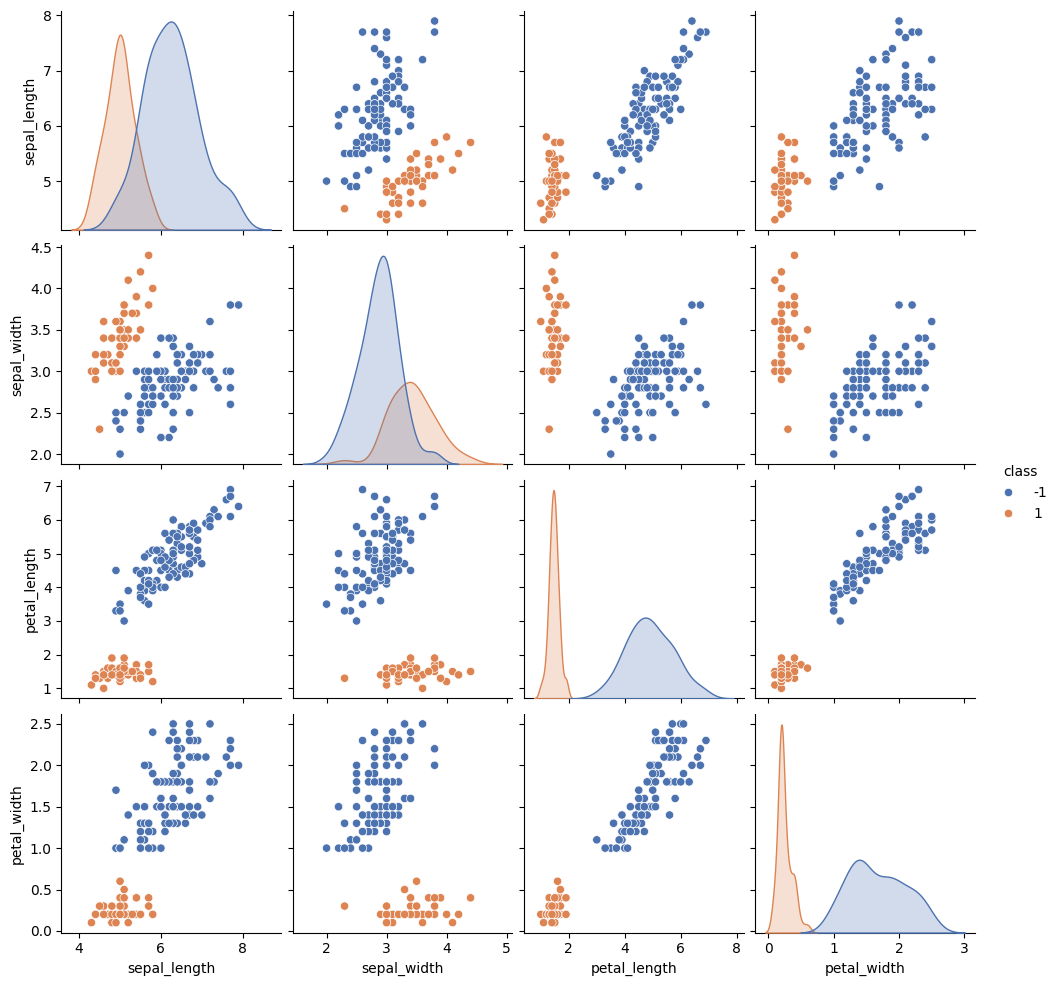

In [9]:
sns.pairplot(data=df, hue='class', palette='deep')

---

### **Hard margin gradient descent**

y = [[-0.35061407]
 [ 0.1474483 ]]x + [0.528]


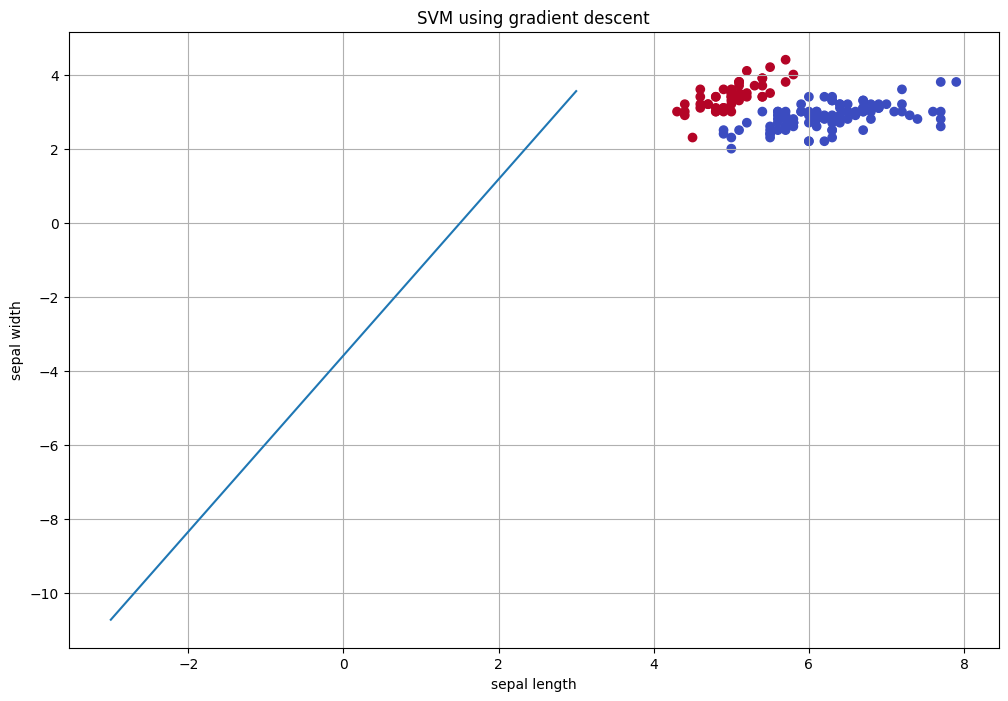

In [45]:
from hard_margin_gd import Hard_margin_GD

X = df[['sepal_length', 'sepal_width']].to_numpy()

y = df['class'].to_numpy()

hard_margin_gd = Hard_margin_GD()
hard_margin_gd.fit(X, y, max_iters=1000, lr=0.001, stats=False)


plt.figure(figsize=(12, 8))
plt.scatter(X[:, 0], X[:, 1], c=y, label='data', cmap='coolwarm')
plt.grid()
plt.xlabel('sepal length')
plt.ylabel('sepal width')
plt.title('SVM using gradient descent')

w1 = hard_margin_gd.weights[0]
w2 = hard_margin_gd.weights[1]
b = hard_margin_gd.bias
print(f'y = {np.array([w1, w2])}x + {b}')

x1 = np.linspace(-3, 3, 100)
x2 =  - ((w1 * x1) + b) / w2

plt.plot(x1, x2)

---